<a href="https://colab.research.google.com/github/PALAK7890/Credit_Risk_Predictor/blob/main/P1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier

In [7]:
url='https://raw.githubusercontent.com/PALAK7890/Credit_Risk_Predictor/refs/heads/main/loan_default_dataset.csv'
df=pd.read_csv(url)
df.head(15)

,customer_id,age,gender,education,employment_type,employment_years,annual_income,loan_amount,debt_to_income_ratio,credit_score,num_previous_loans,missed_payments_last_2yr,defaulted
0,CUST_0031,44.0,male,Bachelor,salaried,17.0,NaN,21029,0.14,613.0,1,13,0
1,CUST_0109,41.0,M,Master,salaried,24.0,40446.0,99848,0.70,408.0,6,9,1
2,CUST_0136,NaN,male,high school,Self-Employed,9.0,59620.0,22015,0.19,NaN,7,10,0
3,CUST_0088,NaN,female,High School,salaried,NaN,50368.0,88820,0.65,439.0,3,1,0
4,CUST_0918,28.0,male,Bachelor,NaN,5.0,29061.0,97446,0.73,603.0,8,2,1
5,CUST_0924,28.0,F,masters,Salaried,26.0,21563.0,91698,0.40,371.0,9,9,0
6,CUST_0870,65.0,male,High School,salaried,22.0,60829.0,53651,NaN,569.0,6,5,0
7,CUST_0318,57.0,F,Bachelor,salaried,NaN,68765.0,30150,0.34,630.0,5,11,0
8,CUST_0261,20.0,Male,NaN,salaried,20.0,50521.0,31390,0.38,784.0,6,12,0
9,CUST_0535,22.0,M,NaN,NaN,NaN,40322.0,19567,0.63,419.0,9,11,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               1030 non-null   object 
 1   age                       945 non-null    float64
 2   gender                    875 non-null    object 
 3   education                 897 non-null    object 
 4   employment_type           878 non-null    object 
 5   employment_years          945 non-null    float64
 6   annual_income             949 non-null    float64
 7   loan_amount               1030 non-null   int64  
 8   debt_to_income_ratio      949 non-null    float64
 9   credit_score              948 non-null    float64
 10  num_previous_loans        1030 non-null   int64  
 11  missed_payments_last_2yr  1030 non-null   int64  
 12  defaulted                 1030 non-null   int64  
dtypes: float64(5), int64(4), object(4)
memory usage: 104.7+ KB


<Axes: >

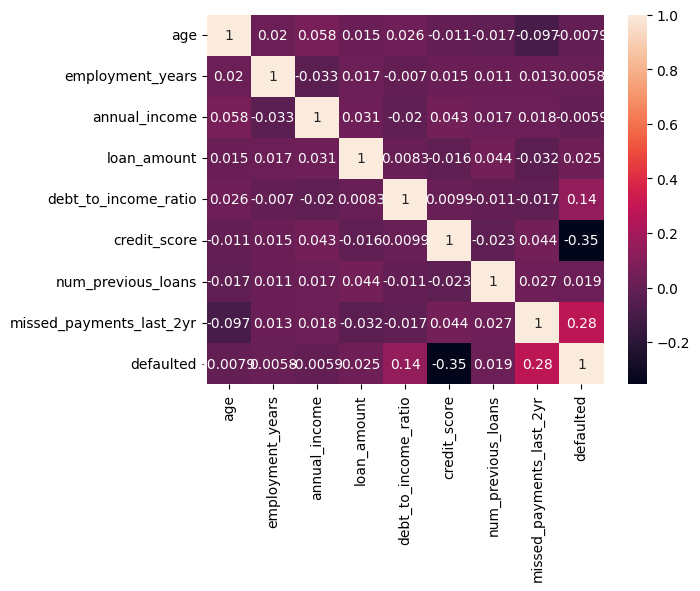

In [9]:
df_num=df.select_dtypes(include='number')
sns.heatmap(df_num.corr(),annot=True,)

In [10]:
df.duplicated().sum()

np.int64(30)

In [11]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [12]:
df['gender']=df['gender'].str.lower().str.strip().str[0]

df['education']=df['education'].str.lower().str.strip()
mapping = {
    'high school': 'High School',
    'bachelor': 'Bachelor',
    'master': 'Master',
    'masters': 'Master',
    'phd': 'PhD'
}

df['education'] = df['education'].map(mapping)
df['employment_type']=df['employment_type'].str.lower().str.strip()


<Axes: >

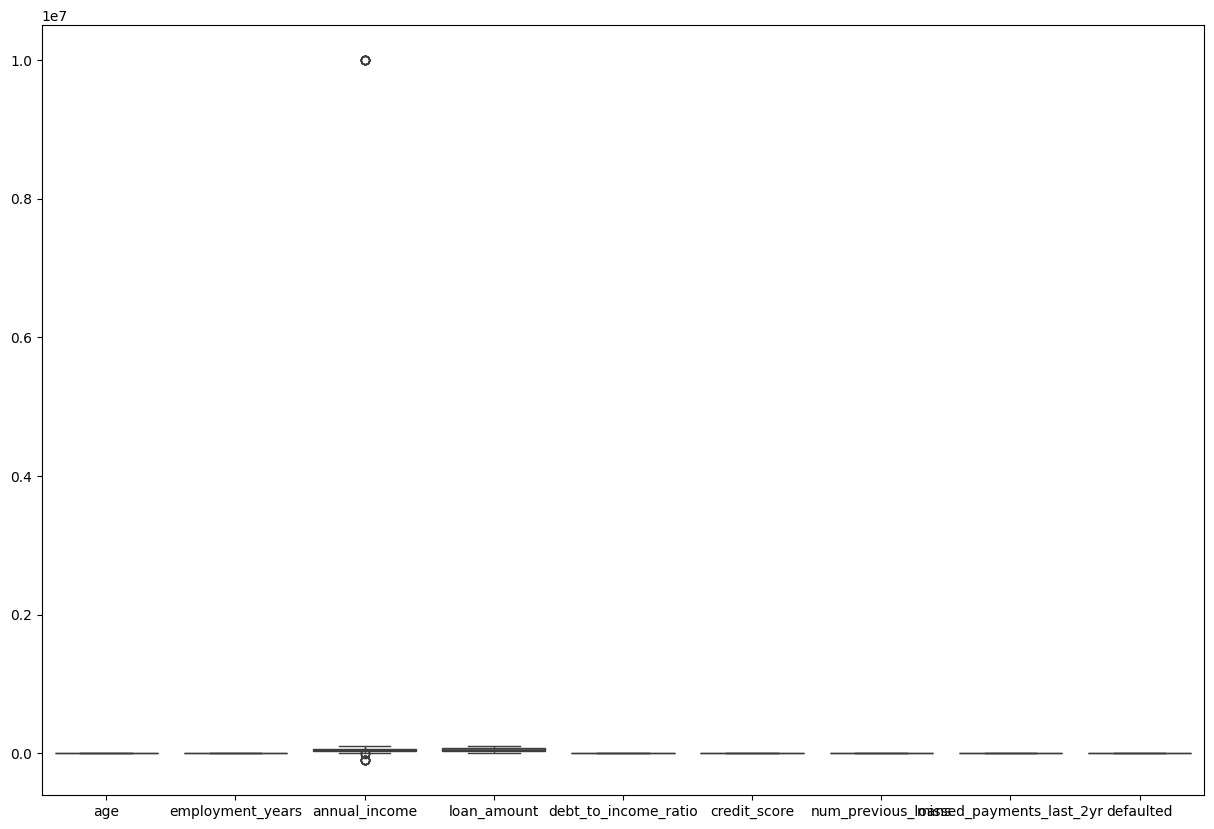

In [13]:
plt.figure(figsize=(15,10))
sns.boxplot(df_num)

In [14]:
df_num.isnull().sum()

,0
age,85
employment_years,85
annual_income,81
loan_amount,0
debt_to_income_ratio,81
credit_score,82
num_previous_loans,0
missed_payments_last_2yr,0
defaulted,0


In [15]:
Q1 = df['annual_income'].quantile(0.25)
Q3 = df['annual_income'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[df['annual_income'].between(lower, upper)]

In [16]:
df['age']=df['age'].fillna(df['age'].median())
df['employment_years']=df['employment_years'].fillna(df['employment_years'].median())
df['annual_income']=df['annual_income'].fillna(df['annual_income'].median())
df['debt_to_income_ratio']=df['debt_to_income_ratio'].fillna(df['debt_to_income_ratio'].median())
df['credit_score']=df['credit_score'].fillna(df['credit_score'].median())

In [17]:
df['gender']=df['gender'].fillna(df['gender'].mode()[0])
df['education']=df['education'].fillna(df['education'].mode()[0])
df['employment_type']=df['employment_type'].fillna(df['employment_type'].mode()[0])
df.drop('customer_id',inplace=True,axis=1)

In [18]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[['High School', 'Bachelor', 'Master', 'PhD']])
df['education'] = oe.fit_transform(df[['education']])

df=pd.get_dummies(df,columns=['employment_type','gender'],drop_first=True)

In [19]:
from sklearn.model_selection import train_test_split
X=df.drop('defaulted',axis=1)
y=df['defaulted']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [20]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train_scaled=sc.fit_transform(X_train)
x_test_scaled=sc.transform(X_test)

In [57]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(class_weight='balanced',max_iter=1000)
model.fit(x_train_scaled,y_train)
pred_logistic=model.predict(x_test_scaled)

In [58]:
from sklearn.tree import DecisionTreeClassifier
model1=DecisionTreeClassifier(class_weight='balanced',random_state=42,max_depth=5)
model1.fit(x_train_scaled,y_train)
pred_tree=model1.predict(x_test_scaled)

In [77]:
from sklearn.ensemble import RandomForestClassifier
model_forest=RandomForestClassifier(n_estimators=100,class_weight='balanced',random_state=42,max_depth=10,min_samples_leaf=5)
model_forest.fit(x_train_scaled,y_train)
pred_forest=model_forest.predict(x_test_scaled)


In [60]:
from sklearn.metrics import accuracy_score,roc_auc_score
acc_logistic=accuracy_score(y_test,pred_logistic)
roc_logistic=roc_auc_score(y_test,pred_logistic)
acc_logistic,roc_logistic

(0.7016574585635359, np.float64(0.7009081983308787))

In [61]:
acc_tree=accuracy_score(y_test,pred_tree)
roc_tree=roc_auc_score(y_test,pred_tree)
acc_tree,roc_tree

(0.7348066298342542, np.float64(0.7334315169366716))

In [78]:
acc_forest=accuracy_score(y_test,pred_forest)
roc_forest=roc_auc_score(y_test,pred_forest)
acc_forest,roc_forest

(0.712707182320442, np.float64(0.7112174766813942))

In [79]:
from sklearn.metrics import classification_report

print("--- Logistic Regression ---")
print(classification_report(y_test, pred_logistic))

print("--- Decision Tree ---")
print(classification_report(y_test, pred_tree))

print("--- Random Forest ---")
print(classification_report(y_test, pred_forest))

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.73      0.71      0.72        97
           1       0.67      0.69      0.68        84

    accuracy                           0.70       181
   macro avg       0.70      0.70      0.70       181
weighted avg       0.70      0.70      0.70       181

--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.75      0.75      0.75        97
           1       0.71      0.71      0.71        84

    accuracy                           0.73       181
   macro avg       0.73      0.73      0.73       181
weighted avg       0.73      0.73      0.73       181

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.73      0.73      0.73        97
           1       0.69      0.69      0.69        84

    accuracy                           0.71       181
   macro avg       0.71      0.71      0.71       181
we